<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/Symbionts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Setup & Academic Visualization Styling
This block loads the essential data-wrangling and plotting packages while setting up a high-resolution, peer-review-ready graphic aesthetic.

In [1]:
# BLOCK 1: Environment Setup & Scientific Theming
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Install scikit-bio quietly to handle multivariate distance matrices
!pip install scikit-bio --quiet
from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 20,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "svg.fonttype": "none" # Protects text vectors for journal export
})
sns.set_theme(style="white", font="serif")

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

global_fig_size = (10, 6)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6
# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print("✨ Block 1: Global environment and styling configured successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 77.3 MB/s eta 0:00:00
✨ Block 1: Global environment and styling configured successfully.


# Block 2: Data Loading & Phenotype Mapping
This block loads your wide CSV file and uses a conditional function to split your biological samples exactly as you defined: pl_101 to pl_107 are tagged as HF, and pl_111 to pl_119 are tagged as NF.

In [2]:
# BLOCK 2: Data Loading & Conditional Phenotype Assignment

# 1. Load the wide-format read proportion dataset
csv_filename = "symbiont_species_read_proportions_wide.csv"
df = pd.read_csv(csv_filename)

# Clean column headers and sample string IDs of any hidden spaces
df.columns = df.columns.str.strip()
df['sample'] = df['sample'].astype(str).str.strip()

# 2. Map sample IDs to host phenotypic cohorts (HF vs NF)
def assign_morph(sample_id):
    # Extract the numeric part of the sample label (e.g., "pl_101" -> 101)
    try:
        num = int(sample_id.split('_')[1])
        if 101 <= num <= 107:
            return 'HF'
        elif 111 <= num <= 119:
            return 'NF'
        else:
            return 'Unknown'
    except:
        return 'Unknown'

df['morph'] = df['sample'].apply(assign_morph)

# Filter out any unmapped validation rows if present
df = df[df['morph'] != 'Unknown'].copy()

# Sort data to ensure crisp block grouping on the X-axis
df = df.sort_values(by=['morph', 'sample']).reset_index(drop=True)

print(f"📊 Block 2: Successfully loaded {len(df)} larval profiles.")
print(df[['sample', 'morph']])

📊 Block 2: Successfully loaded 10 larval profiles.
   sample morph
0  pl_101    HF
1  pl_102    HF
2  pl_104    HF
3  pl_106    HF
4  pl_107    HF
5  pl_111    NF
6  pl_112    NF
7  pl_113    NF
8  pl_118    NF
9  pl_119    NF


In [6]:
name_mapping = {
    'Dtrenchii': 'Durusdinium trenchii',
    'BrevMin': 'Breviolum minutum',
    'SymbA3': 'Symbiodinium clade A3',
    'Stri': 'Symbiodinium tridacnidorum',
    'SPilosum': 'Symbiodinium pilosum',
    'Snat': 'Symbiodinium natans',
    'SMicReefgen': 'Symbiodinium microadriaticum (ReefGenomics)',
    'SMicUQSCI': 'Symbiodinium microadriaticum (UQ)',
    'SMicUQCass': 'Symbiodinium microadriaticum (UQ Cass)',
    'Slin': 'Symbiodinium linucheae',
    'SKawaF': 'Fugacium kawagutii',
    'SGoreauC': 'Cladocopium goreau',
    'CladC15': 'Cladocopium C15'
}

# Rename the columns in the main dataframe
df = df.rename(columns=name_mapping)

# Update the taxa_cols list to reflect the new names
taxa_cols = [name_mapping.get(col, col) for col in taxa_cols]

print("✅ Taxa names updated to full scientific nomenclature.")
display(df.head())

✅ Taxa names updated to full scientific nomenclature.


,sample,Breviolum minutum,Cladocopium C15,Durusdinium trenchii,Cladocopium goreau,Fugacium kawagutii,Symbiodinium microadriaticum (ReefGenomics),Symbiodinium microadriaticum (UQ Cass),Symbiodinium microadriaticum (UQ),Symbiodinium pilosum,Symbiodinium linucheae,Symbiodinium natans,Symbiodinium tridacnidorum,Symbiodinium clade A3,morph
0,pl_101,0.065039,0.056529,0.001346,0.028264,0.000000,0.379544,0.109043,0.126513,0.000000,0.033647,0.020660,0.085202,0.094213,HF
1,pl_102,0.086820,0.024254,0.000000,0.026715,0.000000,0.441430,0.112304,0.133190,0.002318,0.028315,0.005681,0.061753,0.077219,HF
2,pl_104,0.098039,0.091575,0.006464,0.081699,0.003268,0.352938,0.068627,0.055559,0.000000,0.016340,0.013072,0.111111,0.101307,HF
3,pl_106,0.134403,0.071146,0.000000,0.134387,0.003953,0.312253,0.110672,0.083004,0.000000,0.023700,0.007905,0.055336,0.063241,HF
4,pl_107,0.137036,0.096649,0.005917,0.102564,0.001972,0.347126,0.072978,0.072988,0.001972,0.021696,0.019724,0.064150,0.055227,HF


# Block 3: Layout Option A – Faceted Individual Profiles
This script improves your collaborator’s plot by splitting the single continuous row into side-by-side subpanels. This visually isolates the HF block from the NF block so reviewers can immediately scan and see that the colors match perfectly.

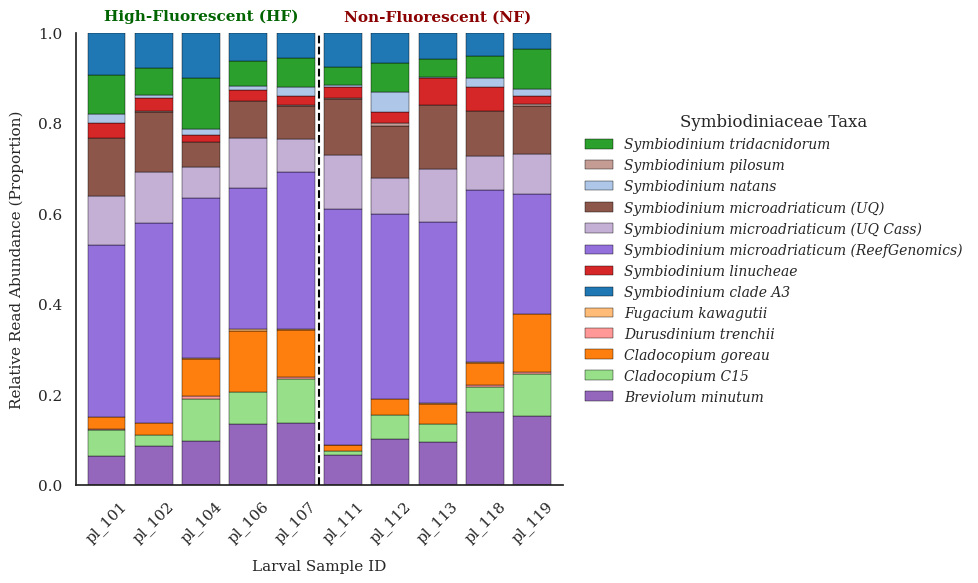

In [50]:
#BLOCK 3: Single Canvas Stacked Bar Chart with Group Divider Line

# 1. Isolate taxa columns in standard order for the plot
taxa_cols = [col for col in df.columns if col not in ['sample', 'morph']]

# Set the 'sample' column as our index so it serves as the X-axis labels
df_plot = df.set_index('sample')

# 2. Count exactly how many HF samples we have to place the line accurately
num_hf = len(df[df['morph'] == 'HF'])

# Initialize a clean, wide standalone figure
fig, ax = plt.subplots(figsize=(10, 6))

# Use a stronger, high-contrast discrete palette ('tab20') using the modern API
import matplotlib as mpl
import random

color_map = mpl.colormaps['tab20']
# Generate color list and shuffle them for a new visual variety
strong_colors = [color_map(i % 20) for i in range(len(taxa_cols))]
# Shuffle the colors (using seed 123 for consistency)
random.seed(123)
random.shuffle(strong_colors)

# IDENTIFY HIGHEST VALUE TAXON AND MAKE IT LIGHT PURPLE
dominant_idx = df[taxa_cols].mean().argmax()
strong_colors[dominant_idx] = 'mediumpurple'  # Updated to a light purple shade

# 3. Plot all samples together on a single canvas (standard order)
df_plot[taxa_cols].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=strong_colors,
    width=0.8,
    edgecolor='black',
    linewidth=0.3
)

# 4. DRAW THE DIVIDER LINE
divider_position = num_hf - 0.5
ax.axvline(x=divider_position, color='black', linestyle='--', linewidth=1.5, zorder=4)

# 5. ADD TERRITORY LABELS AT THE TOP
ax.text(num_hf / 2 - 0.5, 1.02, 'High-Fluorescent (HF)',
        fontsize=11, fontweight='bold', color='darkgreen', ha='center', va='bottom')

total_samples = len(df)
ax.text(num_hf + (total_samples - num_hf) / 2 - 0.5, 1.02, 'Non-Fluorescent (NF)',
        fontsize=11, fontweight='bold', color='darkred', ha='center', va='bottom')

# 6. Formatting Axis and Borders
ax.set_xlabel('Larval Sample ID', fontsize=11, labelpad=10)
ax.set_ylabel('Relative Read Abundance (Proportion)', fontsize=11, labelpad=10)
ax.set_ylim(0, 1.0)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', rotation=45)

# 7. REVERSE ONLY THE LEGEND ORDER (Z to A)
handles, labels = ax.get_legend_handles_labels()
# Sort labels and handles alphabetically, then reverse for Z to A
sorted_pairs = sorted(zip(labels, handles), key=lambda x: x[0], reverse=True)
sorted_labels, sorted_handles = zip(*sorted_pairs)

# Place the legend with reverse-ordered labels and italicized 10pt font
ax.legend(sorted_handles, sorted_labels, loc='center left', title='Symbiodiniaceae Taxa',
          bbox_to_anchor=(1.02, 0.5), frameon=False,
          prop={'style': 'italic', 'size': 10})

plt.tight_layout()
plt.savefig('Symbiont_Composition.png', bbox_inches='tight', dpi=600)
plt.savefig('Symbiont_Composition.pdf', bbox_inches='tight', dpi=600)
plt.savefig('Symbiont_Composition.svg', bbox_inches='tight', dpi=600)
plt.savefig('Symbiont_Composition.tiff', bbox_inches='tight', dpi=600)

plt.show()

# BLOCK 5: Multivariate PERMANOVA & Univariate Strain Testing

In [4]:
# BLOCK 5: Multivariate PERMANOVA & Univariate Strain Testing

# 1. Install scikit-bio to handle ecicological distance matrices
!pip install scikit-bio --quiet

from skbio.stats.distance import permanova, DistanceMatrix
from scipy.spatial.distance import pdist, squareform
from scipy.stats import shapiro, ttest_ind, mannwhitneyu

print("🔄 Computing community matrices...")

# 2. RUN MULTIVARIATE PERMANOVA
# Extract purely the relative abundance matrix data
matrix_data = df[taxa_cols].values

# Calculate a standard ecological Bray-Curtis dissimilarity matrix
bray_curtis_distances = pdist(matrix_data, metric='braycurtis')
distance_matrix_square = squareform(bray_curtis_distances)

# Convert to a scikit-bio tracking matrix framework
skb_dm = DistanceMatrix(distance_matrix_square, ids=df['sample'].tolist())

# Execute PERMANOVA with 999 random permutations to test host morph grouping
permanova_results = permanova(skb_dm, grouping=df['morph'].tolist(), permutations=999)

print("\n🌿 --- MULTIVARIATE COMMUNITY STATISTICS ---")
print(f"PERMANOVA Pseudo-F statistic: {permanova_results['test statistic']:.4f}")
print(f"PERMANOVA p-value:            {permanova_results['p-value']:.4f}")

# 3. RUN UNIVARIATE TEST ON THE DOMINANT TAXON
# Identify the strain with the highest global mean across your rows
dominant_strain = df[taxa_cols].mean().idxmax()

hf_strain_vals = df[df['morph'] == 'HF'][dominant_strain]
nf_strain_vals = df[df['morph'] == 'NF'][dominant_strain]

# Validate distribution shape via Shapiro-Wilk test
_, p_hf = shapiro(hf_strain_vals)
_, p_nf = shapiro(nf_strain_vals)

print(f"\n🧬 --- TARGETED UNIVARIATE STATISTICS ({dominant_strain}) ---")
if p_hf > 0.05 and p_nf > 0.05:
    # Parametric assessment
    t_stat, uni_p = ttest_ind(hf_strain_vals, nf_strain_vals, equal_var=False)
    print(f"Welch's T-test statistic: {t_stat:.4f}")
    print(f"T-test p-value:           {uni_p:.4f}")
else:
    # Non-parametric fallback assessment
    u_stat, uni_p = mannwhitneyu(hf_strain_vals, nf_strain_vals)
    print(f"Mann-Whitney U statistic: {u_stat:.4f}")
    print(f"Mann-Whitney p-value:     {uni_p:.4f}")

🔄 Computing community matrices...

🌿 --- MULTIVARIATE COMMUNITY STATISTICS ---
PERMANOVA Pseudo-F statistic: 0.7412
PERMANOVA p-value:            0.4870

🧬 --- TARGETED UNIVARIATE STATISTICS (SMicReefgen) ---
Welch's T-test statistic: -0.6116
T-test p-value:           0.5630


### Summary Table: Mean Relative Abundance
This table summarizes the average proportions of each taxon across the two phenotypic groups.

In [9]:
# Calculate mean abundance grouped by morph
mean_abundance_table = df.groupby('morph')[taxa_cols].mean().T

# Sort by the HF group's abundance to highlight dominant strains
mean_abundance_table = mean_abundance_table.sort_values(by='HF', ascending=False)

# Format for display
print("📊 Mean Relative Abundance by Morph Group")
display(mean_abundance_table.style.format("{:.4f}").background_gradient(cmap='Greens', axis=1))

📊 Mean Relative Abundance by Morph Group


morph,HF,NF
Symbiodinium microadriaticum (ReefGenomics),0.3667,0.3948
Breviolum minutum,0.1043,0.1149
Symbiodinium microadriaticum (UQ Cass),0.0947,0.0958
Symbiodinium microadriaticum (UQ),0.0943,0.1177
Symbiodinium clade A3,0.0782,0.0578
Symbiodinium tridacnidorum,0.0755,0.0560
Cladocopium goreau,0.0747,0.0535
Cladocopium C15,0.0680,0.0508
Symbiodinium linucheae,0.0247,0.0354
Symbiodinium natans,0.0134,0.0178


### Block 6: Reproducibility & Software Versioning
This block documents the specific software versions used to generate these results, ensuring transparency and reproducibility for peer review.

In [5]:
import sys
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import scipy
import skbio

print("--- Software Version Registry ---")
print(f"Python:     {sys.version.split()[0]}")
print(f"Pandas:     {pd.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"Seaborn:    {sns.__version__}")
print(f"SciPy:      {scipy.__version__}")
print(f"Scikit-Bio: {skbio.__version__}")

--- Software Version Registry ---
Python:     3.13.15
Pandas:     2.2.3
NumPy:      2.1.3
Matplotlib: 3.10.0
Seaborn:    0.13.2
SciPy:      1.16.3
Scikit-Bio: 0.7.3
